# ERP analysis using MNE




TO DO:
- Add original authors
- Update the top-down overview
- Fix exercise 7 on permutation
- See TO DOs in the code blocks

## Top-down view onto this notebook


- basics of ERP analysis and classification 
- commonly used toolboxes, like mne and sklearn
- real EEG data
- This notebook goes through several of the basic steps that are involved in an ERP-pipeline
    - reading the data
    - preprocessing of the data
    - feature extraction
    - classification using cross-validation
    - and evaluation including statistics. 
1. Exercise 1: dataset & environment
1. Exercise 2: load the dataset and preprocess it
1. Exercise 3: visualize both the temporal & spatial distributions of basic ERPs for each of the conditions in the dataset and inspect these
1. (Removed) Exercise 4: Spatial info: decode target vs non-target responses using LDA
1. (Remoevd) Exercise 5: Temporal info: ''
1. Exercise 6: Spatio-temporal info: ''
1. Exercise 7: permutation testing, a powerful tool to assess whether a specific test statistic (here classification accuracy) is significantly higher than chance. 


In [2]:
import glob
import os
import warnings
import yaml

from matplotlib import pyplot as plt
import mne
import numpy as np
from sklearn.model_selection import cross_val_score
from toeplitzlda.classification import ToeplitzLDA # Added (as done in eeg tutorial)
# TO DO: add Simon's implementation of toeplitzlda

# The following imported modules are not in the eeg tutorial. Maybe to be removed later
import re 
from pathlib import Path
import logging
import pickle
import seaborn as sns
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
warnings.simplefilter(action='ignore', category=RuntimeWarning)
sns.set_style('whitegrid')
np.random.seed(42)

# From here on the following three lines are also in the eeg tutorial
mne.set_log_level('WARNING')
warnings.simplefilter(action='ignore', category=RuntimeWarning) # Added (as done in eeg tutorial)
warnings.simplefilter(action='ignore', category=FutureWarning) # Added (as done in eeg tutorial)

## Exercise 1: Download and setup data


Dataset from [Zenodo](https://zenodo.org/record/4066633):
- three subjects, 1 session each.
- Within a session, a resting state recording with eyes open and eyes closed has been performed at the beginning and the end, which you can ignore. 
- Main part of the session: an auditory oddball paradigm was executed. 
- For two different stimulus onset asynchrony (SOA) values, a fast and a slow condition, 40 trials of oddball ERP data were collected. 
- Within a trial, you should find 90 stimuli (75 low-pitched non-targets and 15 high-pitched targets). 
- Please note, that the actual SOA values vary between subjects.

In [6]:
# Adjust this CONFIG_FILE_PATH to point to the config.yaml file
CONFIG_FILE_PATH = os.path.join(os.getcwd(), '../datasets/data_a6', 'config.yaml')

# Load the file
conf = yaml.load(open(CONFIG_FILE_PATH, 'r'), Loader=yaml.FullLoader)

## Exercise 2: Loading and processing ERP data


The first preprocessing steps are performed on the continous data, while later preprocessing steps are performed on time windows of data (so called epochs), which are cut out from the continuous data relative to the onset of every stimulus.

Preprocessing steps:
- Bandpass filtering
- Selecting only EEG channels
- Epoching
- Baselining

Finally, we have concatenated all loaded files into one variable that contains all preprocessed EEG epochs for one subject/condition pair.


In [7]:
def get_file_list(data_path, session, condition):
    sep = os.path.sep
    search_path = f'{data_path}{sep}{session}{sep}*{condition}.vhdr'
    print(f'Loading files matching {search_path}')
    return sorted(glob.glob(search_path))


#def preprocessed_to_epoch(preprocessed_data, decimate=10, baseline_ival=(-.2, 0)): # old one
def preprocessed_to_epoch(preprocessed_data, decimate=10, baseline_ival=None): 
    raw_stim_ids = {"Stimulus/S  1": 1, "Stimulus/S 21": 2}
    class_ids = {"Target": 2, "Non-target": 1}
    reject = dict()
    # reject = dict(eeg=60 * 1e-6)
    events = mne.events_from_annotations(preprocessed_data, event_id=raw_stim_ids)[0]
    epo_data = mne.Epochs(preprocessed_data, events, event_id=class_ids,
                          baseline=baseline_ival, decim=decimate,
                          reject=reject, proj=False, preload=True)
    return epo_data

# conf['data_path'] = os.path.join('/Users/matthias.dold/workspace/teaching/BCI2223/assignment6/data/')
non_eeg_channels = ['EOGvu', 'x_EMGl', 'x_GSR', 'x_Respi', 'x_Pulse', 'x_Optic']
local_data_path = conf['data_path']
session_list = conf['auditory_oddball']['session_list']
condition_list = conf['auditory_oddball']['condition_list']

all_data = dict()
filter_band = (1.5, 16)

baseline_ival = None  # (-.2, 0)

for session in session_list:
    for condition in condition_list:
        
        # Find files
        eeg_filepaths = get_file_list(conf['data_path'], session, condition)

        # Read, preprocess, and slice the data
        epo_arr = []
        
        for eeg_filepath in eeg_filepaths:
            
            # Read raw continuous data
            eeg_data = mne.io.read_raw_brainvision(eeg_filepath, misc=non_eeg_channels)

            # Set electrode positions
            eeg_data.set_montage('standard_1020').load_data()


            # Spectral notch filter (added from the eeg tutorial)
            # eeg.notch_filter(freqs=np.arange(notch, eeg.info['sfreq'] / 2, notch))

            # Spectral filter
            eeg_data.filter(filter_band[0], filter_band[1], method='iir') # To switch up the order, put this

            # Select EEG channels only
            eeg_data.pick_types(eeg=True)

            # Slice to epochs
            # Note, includes baselining, downsample, and outlier rejection
            epo_data = preprocessed_to_epoch(eeg_data, baseline_ival=baseline_ival) # Behind this
            
            # Add epochs to dataset
            epo_arr.append(epo_data)
        
        # Add to data stack
        if session not in all_data:
            all_data[session] = dict()
        if condition not in all_data[session]:
            all_data[session][condition] = mne.concatenate_epochs(epo_arr)

print("Done!")

Loading files matching /Users/Soz/Downloads/eeg_tutorial_erp_data\erp_subject_1\*fast.vhdr
Loading files matching /Users/Soz/Downloads/eeg_tutorial_erp_data\erp_subject_1\*slow.vhdr
Loading files matching /Users/Soz/Downloads/eeg_tutorial_erp_data\erp_subject_2\*fast.vhdr
Loading files matching /Users/Soz/Downloads/eeg_tutorial_erp_data\erp_subject_2\*slow.vhdr
Loading files matching /Users/Soz/Downloads/eeg_tutorial_erp_data\erp_subject_3\*fast.vhdr
Loading files matching /Users/Soz/Downloads/eeg_tutorial_erp_data\erp_subject_3\*slow.vhdr
Done!


## Exercise 3: Basic ERP plots



- ERPs are typically computed by averaging all epochs in the dataset that belong to the same condition (for each participant separately, not looking at target vs non-target yet)
- Basic analysis: we visualize the ERPs over time
- Additionally, we define certain time points at which we want to plot the signal topography over the whole scalp. 


In [7]:
def plot_basic_erps():

    scalp_times = (0.0, 0.1, 0.3)

    #scalp_times = (0.080, 0.150, 0.250)  # times for a topoplot (s) # these times were taken from the eeg tutorial

    for session in session_list:
        for condition in condition_list:
            epo = all_data[session][condition]
            
            # Compute ERP
            t_evoked = epo['Target'].average()
            
            # Plot ERP
            t_evoked.plot_joint(title=f'target_{session} - condition: {condition}', times=scalp_times)     

#plot_basic_erps()        

### get_jumping_means function


In [8]:
# Solution adapted, BT-LDA
# X structure changed --> channels first

def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X


clf_ival_boundaries = np.array([0.1, 0.17, 0.23, 0.3, 0.41, 0.5])

# important: n_channels = 1 for exercise 4 (which is removed). Otherwise the cross validation line doesn't work
# lda = ToeplitzLDA(n_channels = 1) 


## Exercise 6: Classification in the spatio-temporal domain
TO DO: Fix the overview

- Classifiers like LDA expect a feature vector, not a spatio-temporal data matrix. 
- --> we simply concatenate the five temporal features for every channel (LDA does not care about the order of the features, but BT-LDA does!). 

- LDA vs sLDA vs BT-LDA: AUC scores
- performance over smaller datasets

### classifier weights visualization for shrinkage (auto)

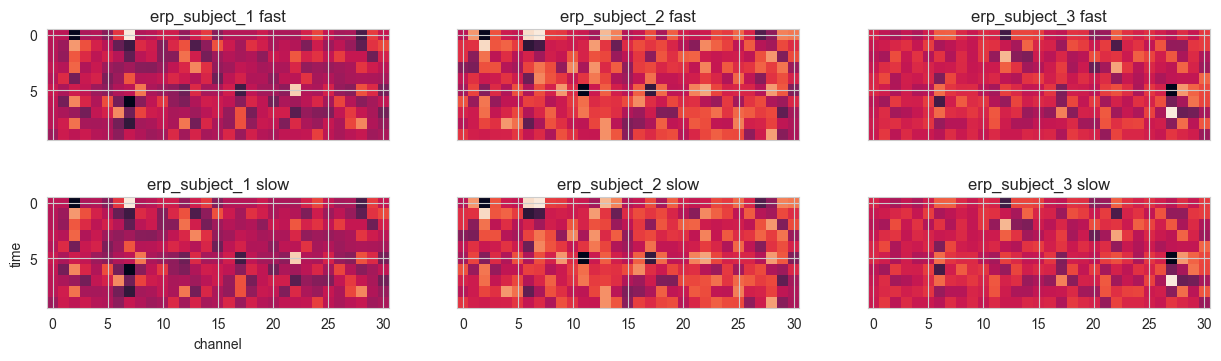

In [10]:
# sLDA
# X structure unchanged
# from assignment 6

epo = all_data[session][condition]
N_conditions = len(condition_list)
clf_ival_boundaries = np.array([0.1, 0.17, 0.23, 0.3, 0.41, 0.5]) # TO DO: change this into equal sizes for BT-LDA, find optimal time intervals
n_channels = len(epo.info["chs"])
n_features = (clf_ival_boundaries.size - 1) * n_channels

parameters = np.zeros((len(session_list), len(condition_list), n_features))
performances = np.zeros((len(session_list), len(condition_list)))
for s_i, session in enumerate(session_list):
    scores = np.zeros((N_conditions,))
    for c_i, condition in enumerate(condition_list):
        
        # Extract the data
        epo = all_data[session][condition]
        X = get_jumping_means(epo, clf_ival_boundaries).squeeze().reshape((-1, n_features))  # flattens
        y = epo.events[:,2]
        
        # Initialize classifier
        lda = LDA(solver='lsqr', shrinkage='auto')
        
        # Learn a model on all data to extract spatio-temporal filter
        parameters[s_i, c_i, :] = lda.fit(X, y).coef_
 

fig, ax = plt.subplots(len(condition_list), len(session_list), sharex=True, sharey=True, figsize=(15, 4))
for s_i, session in enumerate(session_list):
    for c_i, condition in enumerate(condition_list):
        ax[c_i, s_i].imshow(parameters[s_i, :].reshape(n_channels, -1).T)
        ax[c_i, s_i].set_title(f"{session} {condition}")
ax[-1,0].set_xlabel("channel")
ax[-1,0].set_ylabel("time")
plt.show()

# 2. Decodable information: one could inspect the classifier weights. The classifier will learn parameters 
# for each feature i.e. a spatio-temporal filter. You can plot these e.g. as a heatmap(see code). 


### Function for BT-LDA
- This function called `make_channels_first` was created manually to restructure the data matrix X, making it suitable for BT-LDA. 
- However, when using `lda = ToeplitzLDA(n_channels = n_channels)`, you can also pass on another parameter which is False in case the data is not channels first / channel prime. 
- To do: check whether passing on this argument does the same as the additional (external) function `make_channels_first`

In [12]:
def make_channels_first(A):
    """ Changes data matrix of shape (epochs, channels, times) to shape (epochs, times, channels). 
    
    This makes it suitable for BT-LDA where we obtain a channel-wise / channels-first structure when we concatenate features through calling the method .reshape((-1, n_features)) where n_features = times * channels
    
    First check if this input actually holds!
    Input:  data matrix A                   of shape (epochs, channels, times)
    Output: transformed data matrix A_new   of shape (epochs, times, channels)
    
    """

    # In the example case below, we have 1800 epochs, 31 channels, and 5 time intervals

    # Initialize our desired data matrix of shape (1800, 5, 31)
    A_new = np.zeros((A.shape[0], A.shape[2], A.shape[1])) 

    # For every epoch out of 1800 original epochs... note that each original epoch is of shape (31, 5). 
    for e,epoch in enumerate(A): 
        
        # Initialize our desired epoch of shape (5, 31)
        channels_first_epoch = np.zeros((epoch.shape[1],epoch.shape[0])) 

        # for every time interval out of 5 time intervals... 
        #for t,time_ival in enumerate(epoch[1]): # change this into range(epoch.shape[1])?
        for t in range(epoch.shape[1]):    
            
            # keep this time interval constant, and now stack all channels for this time interval within the epoch
            channels_first_epoch[t] = epoch[:,t]

        # add the desired epoch (where the dimensions are swapped) to our desired data matrix
        A_new[e] = channels_first_epoch 
    
    return A_new        

### Plotting average AUC scores (per subject, per condition)

Subject erp_subject_1: session fast: max AUC 0.91 
Subject erp_subject_1: session slow: max AUC 0.85 
Subject erp_subject_2: session fast: max AUC 0.99 
Subject erp_subject_2: session slow: max AUC 0.96 
Subject erp_subject_3: session fast: max AUC 0.90 
Subject erp_subject_3: session slow: max AUC 0.94 
Grand average performance condition fast: 0.93
Grand average performance condition slow: 0.92


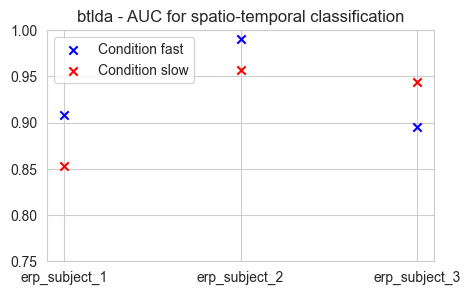

Subject erp_subject_1: session fast: max AUC 0.91 
Subject erp_subject_1: session slow: max AUC 0.86 
Subject erp_subject_2: session fast: max AUC 0.99 
Subject erp_subject_2: session slow: max AUC 0.96 
Subject erp_subject_3: session fast: max AUC 0.90 
Subject erp_subject_3: session slow: max AUC 0.95 
Grand average performance condition fast: 0.93
Grand average performance condition slow: 0.92


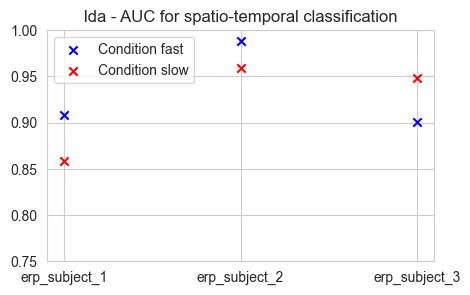

Subject erp_subject_1: session fast: max AUC 0.90 
Subject erp_subject_1: session slow: max AUC 0.84 
Subject erp_subject_2: session fast: max AUC 0.99 
Subject erp_subject_2: session slow: max AUC 0.96 
Subject erp_subject_3: session fast: max AUC 0.88 
Subject erp_subject_3: session slow: max AUC 0.94 
Grand average performance condition fast: 0.92
Grand average performance condition slow: 0.91


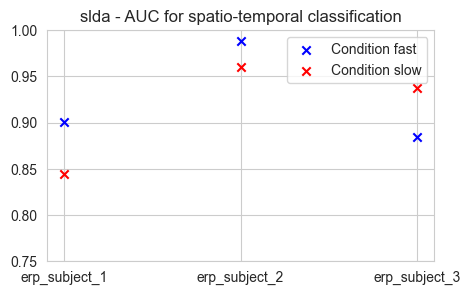

In [ ]:
def plot_spatio_temp_AUC(classifier, all_data):
    """" 
    This function plots the AUC scores for each condition (out of 2), for every subject (out of 3)

    The data matrix X is channel-prime (prerequisite for BT-LDA)

    Input:
    - classifier: (String) classifier name. It is chosen out of the set {"btlda", "slda", "lda"}
    - all_data: dictionary with keys ['erp_subject_1', 'erp_subject_2', 'erp_subject_3']
                key 'erp_subject_1': dict with keys ['fast','slow']
                key 'fast': mne.epochs.EpochsArray containing 1800 epochs

    """

    # TO DO: make clf_ival_boundaries not hard coded
    # TO DO: fix input to obtain n_channels (w/o relying on kernel)
    
    # Check if the classifier argument is valid
    if not isinstance(classifier, str):
        raise ValueError("The argument is not of a valid type. It should be a string")
    elif not classifier in {"lda", "slda", "btlda"}:
        raise ValueError("The provided classifier is not recognized. Only the following are supported: {lda, slda, btlda")

    fig, ax = plt.subplots(1, 1, figsize=(5,3))

    # added contant axes for visualization
    ymin = 0.75
    ymax = 1.00
            
    clf_ival_boundaries = np.array([0.1, 0.17, 0.23, 0.3, 0.41, 0.5])
    epo = all_data['erp_subject_1']['fast'] # TO DO: make this not hard coded
    n_channels = len(epo.info["chs"]) # TO DO: make this not hard coded
    n_features = (clf_ival_boundaries.size - 1) * n_channels
    N_conditions = len(condition_list)

            
    # Initialize classifier
    if classifier == "btlda":
        lda = ToeplitzLDA(n_channels=n_channels)
    elif classifier == "slda":
        lda = LDA(solver='lsqr', shrinkage='auto')
    elif classifier == "lda":
        lda = LDA(solver='lsqr')
    else:
        raise ValueError("Unrecognized classifier")    

    # For each session, for each condition, compute the average AUC score of the classifier
    performances = np.zeros((len(session_list), len(condition_list)))
    for s_i, session in enumerate(session_list):
        scores = np.zeros((N_conditions,))
        for c_i, condition in enumerate(condition_list):
            
            # Extract the data
            epo = all_data[session][condition]
            X = make_channels_first(get_jumping_means(epo, clf_ival_boundaries).squeeze()).reshape((-1, n_features))
            y = epo.events[:,2]
            
            # Evaluate classifier, save average score over folds
            scores[c_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
            
            # Print max score
            print("Subject {}: session {}: max AUC {:.2f} ".format(session, condition, scores[c_i])) 
            performances[s_i, c_i] = scores[c_i]
        
        # Plot scores as scatter
        ax.scatter(session, scores[0], label='Condition fast', color='b', marker='x')
        ax.scatter(session, scores[1], label='Condition slow', color='r', marker='x')
        if s_i == 0:
            plt.legend() 
        ax.set_ylim([ymin, ymax])    
    for c_i, condition in enumerate(condition_list):
        print("Grand average performance condition {}: {:.2f}".format(condition, np.mean(performances[:, c_i])))

    plt.title(f'{classifier} - AUC for spatio-temporal classification')
    plt.show()

plot_spatio_temp_AUC("btlda", all_data)
plot_spatio_temp_AUC("lda", all_data)
plot_spatio_temp_AUC("slda", all_data)

Subject erp_subject_1: session fast: max AUC 0.90 
Subject erp_subject_1: session slow: max AUC 0.87 
Subject erp_subject_2: session fast: max AUC 0.99 
Subject erp_subject_2: session slow: max AUC 0.97 
Subject erp_subject_3: session fast: max AUC 0.91 
Subject erp_subject_3: session slow: max AUC 0.95 
Grand average performance condition fast: 0.94
Grand average performance condition slow: 0.93


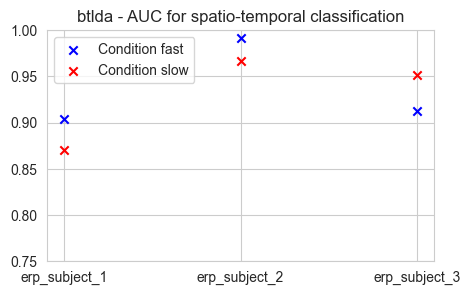

Subject erp_subject_1: session fast: max AUC 0.89 
Subject erp_subject_1: session slow: max AUC 0.86 
Subject erp_subject_2: session fast: max AUC 0.99 
Subject erp_subject_2: session slow: max AUC 0.96 
Subject erp_subject_3: session fast: max AUC 0.89 
Subject erp_subject_3: session slow: max AUC 0.94 
Grand average performance condition fast: 0.92
Grand average performance condition slow: 0.92


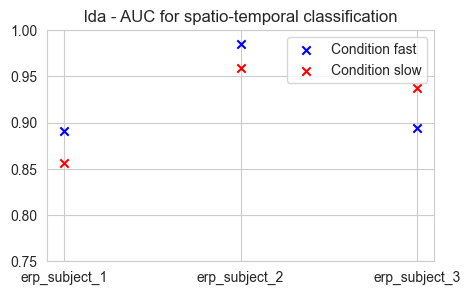

Subject erp_subject_1: session fast: max AUC 0.89 
Subject erp_subject_1: session slow: max AUC 0.85 
Subject erp_subject_2: session fast: max AUC 0.99 
Subject erp_subject_2: session slow: max AUC 0.96 
Subject erp_subject_3: session fast: max AUC 0.90 
Subject erp_subject_3: session slow: max AUC 0.94 
Grand average performance condition fast: 0.92
Grand average performance condition slow: 0.92


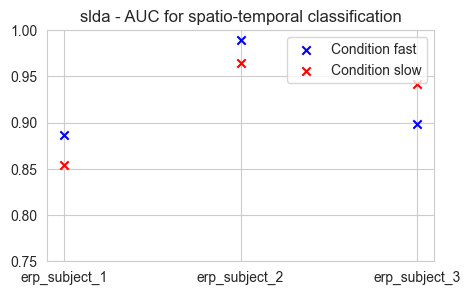

In [17]:
def plot_spatio_temp_AUC(classifier, all_data):
    """" 
    This function plots the AUC scores for each condition (out of 2), for every subject (out of 3)

    The data matrix X is channel-prime (prerequisite for BT-LDA)

    Input:
    - classifier: (String) classifier name. It is chosen out of the set {"btlda", "slda", "lda"}
    - all_data: dictionary with keys ['erp_subject_1', 'erp_subject_2', 'erp_subject_3']
                key 'erp_subject_1': dict with keys ['fast','slow']
                key 'fast': mne.epochs.EpochsArray containing 1800 epochs

    """

    # TO DO: make clf_ival_boundaries not hard coded
    # TO DO: fix input to obtain n_channels (w/o relying on kernel)
    
    # Check if the classifier argument is valid
    if not isinstance(classifier, str):
        raise ValueError("The argument is not of a valid type. It should be a string")
    elif not classifier in {"lda", "slda", "btlda"}:
        raise ValueError("The provided classifier is not recognized. Only the following are supported: {lda, slda, btlda")

    fig, ax = plt.subplots(1, 1, figsize=(5,3))

    # added contant axes for visualization
    ymin = 0.75
    ymax = 1.00
            
    clf_ival_boundaries = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])
    epo = all_data['erp_subject_1']['fast'] # TO DO: make this not hard coded
    n_channels = len(epo.info["chs"]) # TO DO: make this not hard coded
    n_features = (clf_ival_boundaries.size - 1) * n_channels
    N_conditions = len(condition_list)

            
    # Initialize classifier
    if classifier == "btlda":
        lda = ToeplitzLDA(n_channels=n_channels)
    elif classifier == "slda":
        lda = LDA(solver='lsqr', shrinkage='auto')
    elif classifier == "lda":
        lda = LDA(solver='lsqr')
    else:
        raise ValueError("Unrecognized classifier")    

    # For each session, for each condition, compute the average AUC score of the classifier
    performances = np.zeros((len(session_list), len(condition_list)))
    for s_i, session in enumerate(session_list):
        scores = np.zeros((N_conditions,))
        for c_i, condition in enumerate(condition_list):
            
            # Extract the data
            epo = all_data[session][condition]
            X = make_channels_first(get_jumping_means(epo, clf_ival_boundaries).squeeze()).reshape((-1, n_features))
            y = epo.events[:,2]
            
            # Evaluate classifier, save average score over folds
            scores[c_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
            
            # Print max score
            print("Subject {}: session {}: max AUC {:.2f} ".format(session, condition, scores[c_i])) 
            performances[s_i, c_i] = scores[c_i]
        
        # Plot scores as scatter
        ax.scatter(session, scores[0], label='Condition fast', color='b', marker='x')
        ax.scatter(session, scores[1], label='Condition slow', color='r', marker='x')
        if s_i == 0:
            plt.legend() 
        ax.set_ylim([ymin, ymax])    
    for c_i, condition in enumerate(condition_list):
        print("Grand average performance condition {}: {:.2f}".format(condition, np.mean(performances[:, c_i])))

    plt.title(f'{classifier} - AUC for spatio-temporal classification')
    plt.show()

plot_spatio_temp_AUC("btlda", all_data)
plot_spatio_temp_AUC("lda", all_data)
plot_spatio_temp_AUC("slda", all_data)

### Ignore (for my own understanding)

In [14]:
# This whole code cell should be ignored. It was for my own understanding of shapes and how the data is ordered

print(epo) # 1800 epochs
print(get_jumping_means(epo, clf_ival_boundaries).shape) # (1800, 31, 5)
print(get_jumping_means(epo, clf_ival_boundaries).squeeze().shape) # (1800, 31, 5)
A = get_jumping_means(epo, clf_ival_boundaries).squeeze()
A_reshaped = get_jumping_means(epo, clf_ival_boundaries).squeeze().reshape((-1, n_features))
print(get_jumping_means(epo, clf_ival_boundaries).squeeze().reshape((-1, n_features)).shape) # (1800, 155)

#X = get_jumping_means(epo, clf_ival_boundaries).squeeze().reshape((-1, n_features))  # flattens
print(A[0,0,0]) # epoch 0, channel 0, time interval 0 --> -1.44946924217257e-07
print(A_reshaped[0,0]) # same as the line above

print(A[0,1,0]) # epoch 0, channel 1, time interval 0 --> -2.2069827141087027e-06
print(A_reshaped[0,1]) # epoch 0, feature 1 (it is either channel 1 or time interval 1) --> -7.50216367584815e-06

# Trying out manual reshaping
# A is the matrix of n_epochs x n_channels x n_times (n_times is actually the 5 defined time intervals)
A_new = make_channels_first(A)


A_final = A_new.reshape((-1, n_features)) # shape (1800, 155)
print(A_final.shape)

# Check now if its channels first
print(A[0,0,0]) # epoch 0, channel 0, time interval 0 --> -1.44946924217257e-07
print(A_final[0,0]) # same as the line above

print(A[0,1,0]) # epoch 0, channel 1, time interval 0 --> -2.2069827141087027e-06
print(A_final[0,1]) # epoch 0, feature 1 (it is also channel 1 yay!) --> -2.2069827141087027e-06

<EpochsArray | 1800 events (all good), -0.2 – 0.5 s (baseline off), ~30.3 MiB, data loaded,
 'Target': 300
 'Non-target': 1500>
(1800, 31, 5)
(1800, 31, 5)
(1800, 155)
-1.44946924217257e-07
-1.44946924217257e-07
-2.2069827141087027e-06
-7.50216367584815e-06
(1800, 155)
-1.44946924217257e-07
-1.44946924217257e-07
-2.2069827141087027e-06
-2.2069827141087027e-06


### Iterating over smaller datasets

In [ ]:
# AUC is computed with a single sample for each dataset size (this is unstable and unreliable, see auc_repeating_sizes instead)

def auc_single_sizes(sizes, start):
    """" Compute grand avg AUC score for different dataset sizes for all three classifiers (lda, slda, btlda) based on a single sample per size
    
    Input:
    - sizes
    - start: starting epoch for the sample interval. Example: start = 0 gives sample [0,size], while start = 50 gives sample [50,50+size]

    Output:
    - scores_wo: grand avg AUC scores lda
    - scores_w: grand avg AUC scores slda
    - scores_bt: grand avg AUC scores btlda
    """

    scores_wo = np.zeros((len(session_list), len(condition_list), sizes.size)) # lda
    scores_w = np.zeros((len(session_list), len(condition_list), sizes.size)) # slda
    scores_bt = np.zeros((len(session_list), len(condition_list), sizes.size)) # btlda

    for s_i, session in enumerate(session_list):
        for c_i, condition in enumerate(condition_list):
            
            epo = all_data[session][condition]
            #X = get_jumping_means(epo, clf_ival_boundaries).squeeze().reshape((-1, 155)) # old
            # added
            X = make_channels_first(get_jumping_means(epo, clf_ival_boundaries).squeeze()).reshape((-1, n_features)) 
            y = epo.events[:,2]

            lda_wo = LDA(solver='lsqr')
            lda_w = LDA(solver='lsqr', shrinkage='auto')
            lda_bt = ToeplitzLDA(n_channels=n_channels)
            
            for i, size in enumerate(sizes):
                scores_wo[s_i, c_i, i] = cross_val_score(lda_wo, X[start:start+size, :], y[start:start+size], cv=5, scoring='roc_auc').mean()
                scores_w[s_i, c_i, i] = cross_val_score(lda_w, X[start:start+size, :], y[start:start+size], cv=5, scoring='roc_auc').mean()
                scores_bt[s_i, c_i, i] = cross_val_score(lda_bt, X[start:start+size, :], y[start:start+size], cv=5, scoring='roc_auc').mean()

    return scores_wo, scores_w, scores_bt

def plot_smaller_datasets(sizes, scores_wo, scores_w, scores_bt, title ="AUC scores over different dataset sizes"):        
    plt.figure(figsize=(15, 3))
    plt.plot(sizes, np.mean(scores_wo, axis=0)[0].T, label="LDA FAST", color='orange')
    plt.plot(sizes, np.mean(scores_wo, axis=0)[1].T, label="LDA SLOW",linestyle='dashed', color='orange')

    plt.plot(sizes, np.mean(scores_w, axis=0)[0].T, label="sLDA (s = auto) FAST", color='green')
    plt.plot(sizes, np.mean(scores_w, axis=0)[1].T, label="sLDA (s = auto) SLOW", linestyle='dashed', color='green')

    plt.plot(sizes, np.mean(scores_bt, axis=0)[0].T, label="toeplitz FAST", color = 'magenta')
    plt.plot(sizes, np.mean(scores_bt, axis=0)[1].T, label="toeplitz SLOW", linestyle='dashed', color = 'magenta')
    plt.xlabel("dataset size (epochs)")
    plt.ylabel("AUC score")
    plt.title(title)
    plt.legend()
    plt.show()


# To store the obtained AUC scores for later use such as plotting without having to compute the scores again, I implented this function below. 
# Is there a more efficient way to store variables? --> Try out pickl, logging, numpy also has a function to save and load

def print_auc_results(scores_clf, name):
    """ Prints the obtained AUC scores for a certain classifier

    Input:
    - scores_clf: the obtained AUC scores for a classifier (which can be obtained from auc_single_sizes or auc_repeating_sizes)
    - name: (string) the name of the classifier
    
    """
    # Assuming scores_clf (np nd array) has shape (3,2,10)

    # Round to 3 decimals
    scores_clf = scores_clf.round(3)
    format = "\nAUC Scores for classifier {}".format(name)
    format += "\nSubject 1: \n\t Fast condition: {} \n\t Slow condition: {}".format(scores_clf[0][0], scores_clf[0][1])
    format += "\nSubject 2: \n\t Fast condition: {} \n\t Slow condition: {}".format(scores_clf[1][0], scores_clf[1][1])
    format += "\nSubject 3: \n\t Fast condition: {} \n\t Slow condition: {}".format(scores_clf[2][0], scores_clf[2][1])

    print(format)    
    


AUC Scores for classifier s1
Subject 1: 
	 Fast condition: [0.542 0.844 0.914 0.909 0.928 0.913 0.899 0.897 0.906 0.908] 
	 Slow condition: [0.56  0.779 0.834 0.801 0.837 0.825 0.838 0.834 0.851 0.858]
Subject 2: 
	 Fast condition: [0.513 0.943 0.976 0.973 0.982 0.99  0.988 0.986 0.989 0.988] 
	 Slow condition: [0.54  0.87  0.948 0.951 0.954 0.951 0.956 0.95  0.95  0.959]
Subject 3: 
	 Fast condition: [0.498 0.816 0.845 0.852 0.852 0.868 0.864 0.883 0.895 0.9  ] 
	 Slow condition: [0.543 0.854 0.884 0.898 0.925 0.937 0.935 0.939 0.946 0.948]

AUC Scores for classifier s2
Subject 1: 
	 Fast condition: [0.888 0.934 0.926 0.91  0.916 0.904 0.9   0.897 0.898 0.901] 
	 Slow condition: [0.864 0.829 0.85  0.821 0.824 0.81  0.817 0.821 0.832 0.845]
Subject 2: 
	 Fast condition: [0.993 0.992 0.987 0.983 0.986 0.989 0.99  0.986 0.989 0.989] 
	 Slow condition: [0.899 0.933 0.954 0.96  0.956 0.954 0.958 0.956 0.955 0.96 ]
Subject 3: 
	 Fast condition: [0.786 0.818 0.859 0.846 0.852 0.85  0.86  0.

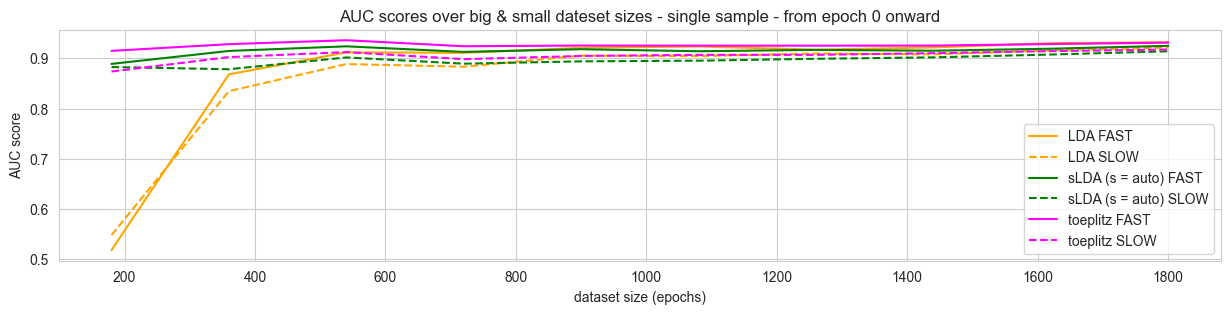

In [14]:
# Test
# How to store the scores? Printing it and saving it manually?
n_epochs = 1800
sizes = np.linspace(n_epochs//10, n_epochs, 10).astype("int")
s1,s2,s3 = auc_single_sizes(sizes,0)
print_auc_results(s1, "s1")
print_auc_results(s2, "s2")
print_auc_results(s3, "s3")
plot_smaller_datasets(sizes,s1,s2,s3,title="AUC scores over big & small dateset sizes - single sample - from epoch 0 onward")


#### Even smaller datasets to compare BT-LDA, sLDA, LDA

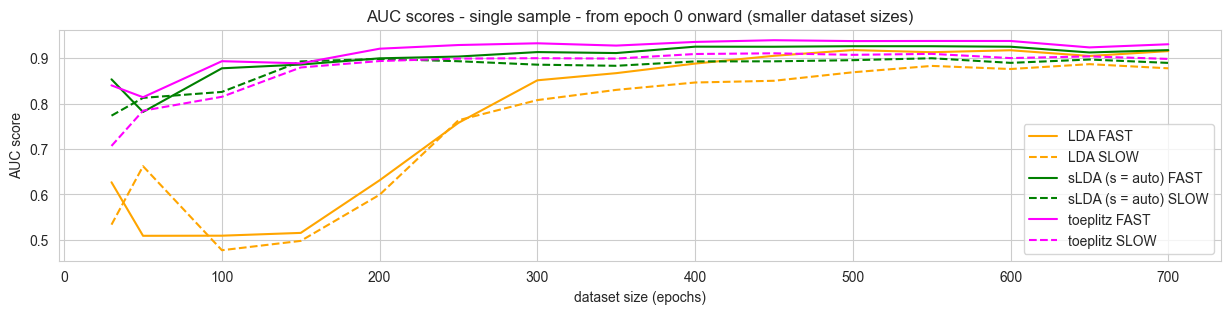

In [ ]:
# Now the smaller dataset sizes are considered only (range [0-700] instead of [0-1800])
sizes = np.array([30,50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700]) # hard coded sizes

s1,s2,s3 = auc_single_sizes(sizes)
plot_smaller_datasets(sizes,s1,s2,s3, "AUC scores - single sample - from epoch 0 onward (smaller dataset sizes)")

## Varying in selecting single dataset samples

From here on, I tried to get a more reliable estimate of classification accuracy. I saw that for every size that we have determined, all epochs up to that number are taken from X and y. However, maybe we should also consider other sample intervals instead of from the start. Therefore, I have decided to extact a sample interval from epoch 50 onward (in this block), from epoch 200 onward (next block), and from epoch 1000 onward.


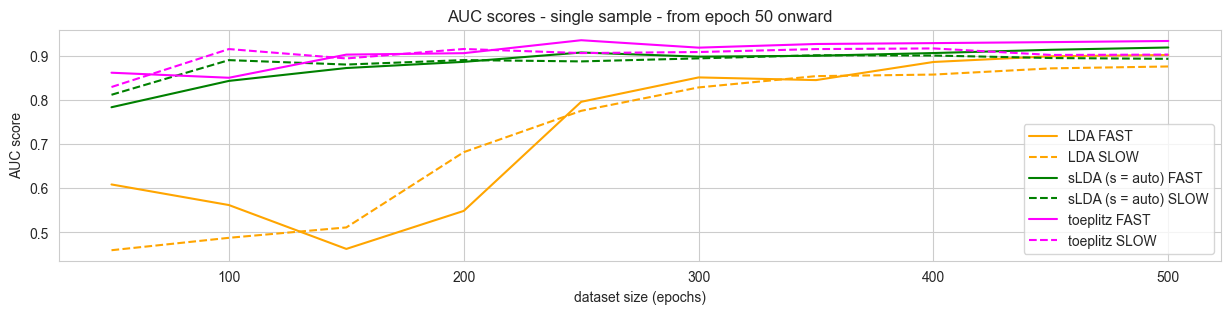

In [ ]:
# single sample from epoch 50 onward (runtime 34 s)
s1,s2,s3 = auc_single_sizes(sizes,50)
plot_smaller_datasets(sizes,s1,s2,s3, "AUC scores - single sample - from epoch 50 onward")

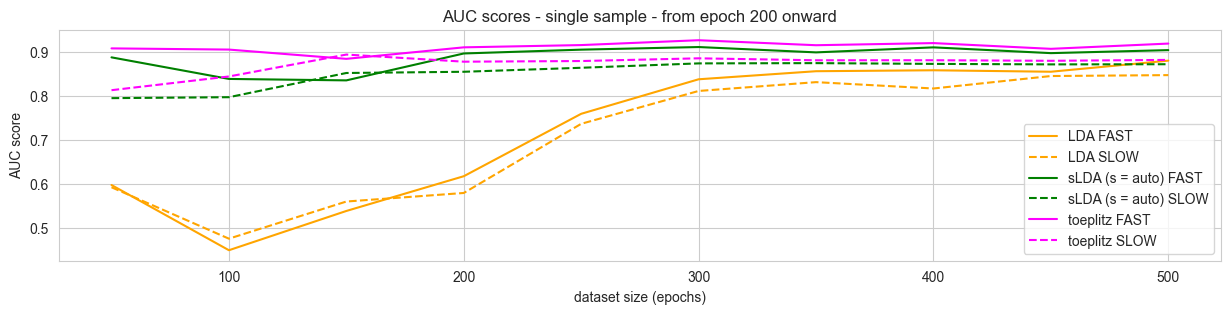

In [ ]:
# single sample from epoch 200 onward (runtime: 37s)
s1,s2,s3 = auc_single_sizes(sizes,200)
plot_smaller_datasets(sizes,s1,s2,s3, "AUC scores - single sample - from epoch 200 onward")

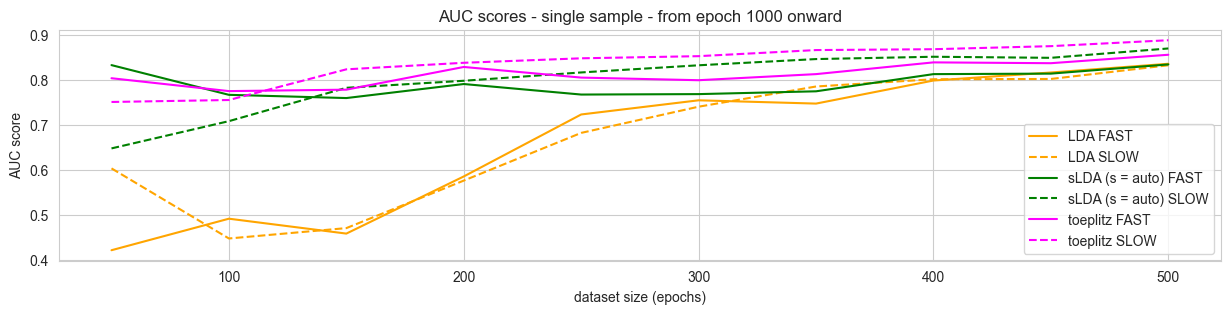

In [ ]:
# single sample from epoch 1000 onward (runtime 46 s)
s1,s2,s3 = auc_single_sizes(sizes,1000)
plot_smaller_datasets(sizes,s1,s2,s3, "AUC scores - single sample - from epoch 1000 onward")

As you see, selecting the interval (from which epoch you sample) changes the outcome of performance! This is problematic, because we want to know the general performance over e.g. a dataset size of 50... To obtain this general performance score, in the following code blocks below I have implemented a function that uses multiple intervals and takes the average over all those intervals. This makes it more robust and stable. Now, the outcome of that function is the general performance over e.g. a dataset size of 50.

## With repetitions: multiple dataset size samples

In [ ]:
all_data = all_data

def auc_repeating_sizes(sizes = np.array([50,100,200,300,400,500]), step_size = 100, tracker=False):
    """ 
    This function computes the AUC scores for the classifiers LDA, sLDA and BTLDA over a set of different dataset sizes.

    The function keeps track of the AUC scores for different dataset sizes per classifier. For each dataset size, multiple samples (repetitions) are taken from the dataset, with a distance step_size between samples. Per dataset size, the number of taken samples is stored in repeats. The average over all samples is computed and its result is the final AUC score for that dataset size.

    Example for dataset size = 50, step_size = 10:
        sample 1 takes interval [50-100]
        sample 2 takes interval [60-110]
        sample 3 takes interval [70-120]
        etc.

    Input:
    - sizes: np array of dataset sizes for which to compute the AUC score per classifier
    - step_size: size of steps to take between samples/repetitions. A low step_size gives a more reliable result, but takes very long to run!
    - tracker: True if you want to follow the process through implemented printing commands. False if you want to disable printing. 

    Output:
    - scores_wo: matrix of size (sessions, conditions, sizes) with the AUC scores for LDA. 
    - scores_w: matrix of size (sessions, conditions, sizes) with the AUC scores for sLDA. 
    - scores_bt: matrix of size (sessions, conditions, sizes) with the AUC scores for BT-LDA. 
    - repeats: np array that keeps track of the number of samples/repetitions for each data set size (taken from `sizes`)

    """
    
    # TO DO: add as input parameters instead of relying on the kernel
    session_list = [session for session in all_data.keys()]
    #condition_list = condition_list
    #all_data = all_data

    n_epochs = 1800 # TO DO: make it not hard coded 
    sizes = sizes

    # store the scores per dataset size in a matrix for each classifier
    scores_wo = np.zeros((len(session_list), len(condition_list), sizes.size))  # lda
    scores_w = np.zeros((len(session_list), len(condition_list), sizes.size))   # slda
    scores_bt = np.zeros((len(session_list), len(condition_list), sizes.size))  # btlda

    # added to keep track of the repetitions per dataset size 
    # the values differ per size, depending on how often the size fits in the full dataset
    repeats = np.array([])

    for s_i, session in enumerate(session_list):
        for c_i, condition in enumerate(condition_list):
            
            # Extract features (channel-prime)
            epo = all_data[session][condition]
            A = get_jumping_means(epo, clf_ival_boundaries).squeeze()
            A_new = make_channels_first(A)
            X = A_new.reshape((-1, n_features))
            y = epo.events[:,2]

            # Initialize the classifiers lda, slda, btlda
            lda_wo = LDA(solver='lsqr')
            lda_w = LDA(solver='lsqr', shrinkage='auto')
            lda_bt = ToeplitzLDA(n_channels=n_channels)
            
            # For every defined dataset size
            for i, size in enumerate(sizes):

                # Repeating: per size it computes the mean auc score (over 5 folds cv) many times, everytime for a new interval 
                # between each interval, steps are taken of given step size.
                # Example: dataset size 50, step size 10 gives the intervals: [50,100], [60,110], [70,120], ..., [1750,1800]

                # to keep track of all calculated auc scores per interval (= per repititon) 
                m1 = np.array([]) # lda 
                m2 = np.array([]) # slda
                m3 = np.array([]) # btlda

                if tracker:
                    print("S{}, C{}, Computing average auc score for size {}".format(s_i,c_i,size))

                # Repeating: loop over all possible intervals starting from the size itself until 1800, taking steps of the given step size
                for j in range(size,n_epochs-size,step_size):

                    if tracker:
                        print("\t interval: [{},{}]".format(j, j+size))

                    m1 = np.append(m1,cross_val_score(lda_wo, X[j:j+size, :], y[j:j+size], cv=5, scoring='roc_auc').mean())
                    m2 = np.append(m2,cross_val_score(lda_w, X[j:j+size, :], y[j:j+size], cv=5, scoring='roc_auc').mean())
                    m3 = np.append(m3,cross_val_score(lda_bt, X[j:j+size, :], y[j:j+size], cv=5, scoring='roc_auc').mean())

                # average the auc score over all repetitions to obtain the value for a certain dataset size
                scores_wo[s_i, c_i, i] = m1.mean() # lda 
                scores_w[s_i, c_i, i] = m2.mean()  # slda
                scores_bt[s_i, c_i, i] = m3.mean() # btlda

                # Keeping track of the number of repetitions per dataset size
                # keep track only for session 1, condition 1. Otherwise we have 6 times the same repeats array
                if s_i == 1 and c_i == 1: 
                    repeats = np.append(repeats,len(m1))
                    
                if tracker:
                    print("avg auc scores: lda {} - slda {} - btlda {}".format(m1.mean(), m2.mean(), m3.mean()))
                    
    return scores_wo, scores_w, scores_bt, repeats        

In [ ]:
# Testing the function auc_repeating_sizes with tracker = True (runtime 6m 1.4s)
# This tracker is only so that you can estimate rougly how long it is taking & where it is in the running process
step_size = 100
sizes = np.array([50,100,200,300,400,500])
scores_wo, scores_w, scores_bt, repeats = auc_repeating_sizes(sizes, step_size = step_size, tracker=True)

S0, C0, Computing average auc score for size 50
	 interval: [50,100]
	 interval: [150,200]
	 interval: [250,300]
	 interval: [350,400]
	 interval: [450,500]
	 interval: [550,600]
	 interval: [650,700]
	 interval: [750,800]
	 interval: [850,900]
	 interval: [950,1000]
	 interval: [1050,1100]
	 interval: [1150,1200]
	 interval: [1250,1300]
	 interval: [1350,1400]
	 interval: [1450,1500]
	 interval: [1550,1600]
	 interval: [1650,1700]
avg auc scores: lda 0.4617647058823529 - slda 0.6964052287581699 - btlda 0.7695261437908496
S0, C0, Computing average auc score for size 100
	 interval: [100,200]
	 interval: [200,300]
	 interval: [300,400]
	 interval: [400,500]
	 interval: [500,600]
	 interval: [600,700]
	 interval: [700,800]
	 interval: [800,900]
	 interval: [900,1000]
	 interval: [1000,1100]
	 interval: [1100,1200]
	 interval: [1200,1300]
	 interval: [1300,1400]
	 interval: [1400,1500]
	 interval: [1500,1600]
	 interval: [1600,1700]
avg auc scores: lda 0.4513288909313725 - slda 0.73097043

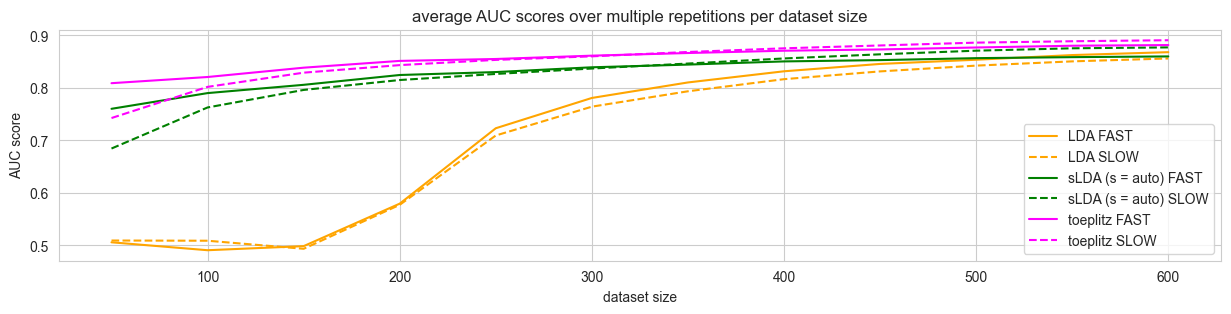

Dataset sizes: 		[ 50 100 150 200 250 300 350 400 450 500 550 600]
Repetitions per size: 	[34. 32. 30. 28. 26. 24. 22. 20. 18. 16. 14. 12.]
Step size: 50


In [114]:
step_size = 50
sizes = np.array([50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600])
scores_wo, scores_w, scores_bt, repeats = auc_repeating_sizes(sizes, step_size = step_size, tracker=False)
# Complete plotting of the above
plt.figure(figsize=(15, 3))
plt.plot(sizes, np.mean(scores_wo, axis=0)[0].T, label="LDA FAST", color='orange')
plt.plot(sizes, np.mean(scores_wo, axis=0)[1].T, label="LDA SLOW",linestyle='dashed', color='orange')

plt.plot(sizes, np.mean(scores_w, axis=0)[0].T, label="sLDA (s = auto) FAST", color='green')
plt.plot(sizes, np.mean(scores_w, axis=0)[1].T, label="sLDA (s = auto) SLOW", linestyle='dashed', color='green')

plt.plot(sizes, np.mean(scores_bt, axis=0)[0].T, label="toeplitz FAST", color = 'magenta')
plt.plot(sizes, np.mean(scores_bt, axis=0)[1].T, label="toeplitz SLOW", linestyle='dashed', color = 'magenta')
plt.xlabel("dataset size")
plt.ylabel("AUC score")
plt.legend()
plt.title("average AUC scores over multiple repetitions per dataset size")
plt.show()

print("Dataset sizes: \t\t{}".format(sizes))
print("Repetitions per size: \t{}".format(repeats))
print("Step size: {}".format(step_size))


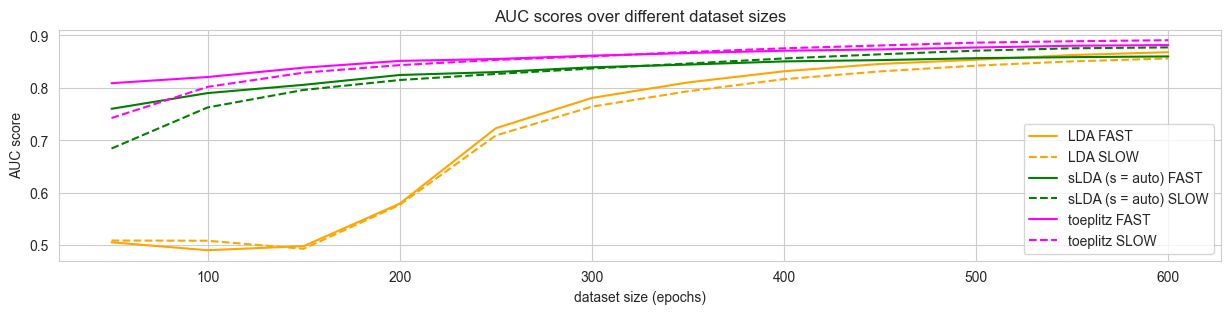

In [95]:
step_size = 50
sizes = np.array([50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600])
scores_wo, scores_w, scores_bt, repeats = auc_repeating_sizes(sizes, step_size = step_size, tracker=False)
plot_smaller_datasets(sizes, scores_wo, scores_w, scores_bt)

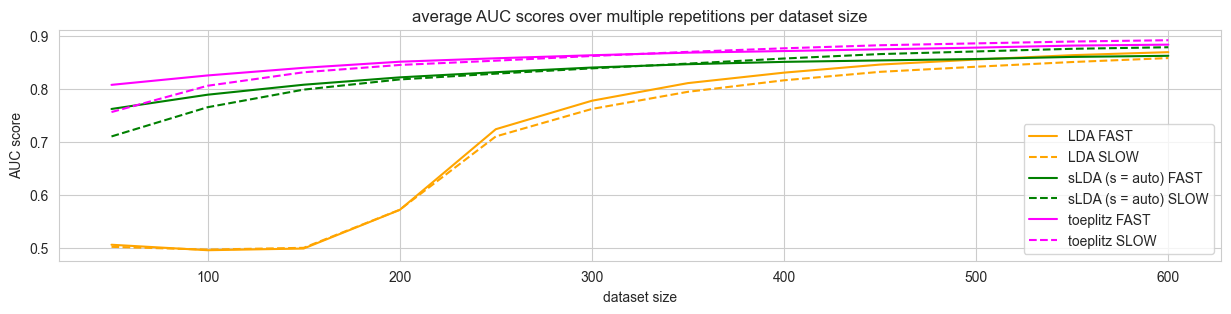

Dataset sizes: 		[ 50 100 150 200 250 300 350 400 450 500 550 600]
Repetitions per size: 	[85. 80. 75. 70. 65. 60. 55. 50. 45. 40. 35. 30.]
Step size: 20


In [115]:
step_size = 20
sizes = np.array([50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600])
scores_wo, scores_w, scores_bt, repeats = auc_repeating_sizes(sizes, step_size = step_size, tracker=False)
# Complete plotting of the above
plt.figure(figsize=(15, 3))
plt.plot(sizes, np.mean(scores_wo, axis=0)[0].T, label="LDA FAST", color='orange')
plt.plot(sizes, np.mean(scores_wo, axis=0)[1].T, label="LDA SLOW",linestyle='dashed', color='orange')

plt.plot(sizes, np.mean(scores_w, axis=0)[0].T, label="sLDA (s = auto) FAST", color='green')
plt.plot(sizes, np.mean(scores_w, axis=0)[1].T, label="sLDA (s = auto) SLOW", linestyle='dashed', color='green')

plt.plot(sizes, np.mean(scores_bt, axis=0)[0].T, label="toeplitz FAST", color = 'magenta')
plt.plot(sizes, np.mean(scores_bt, axis=0)[1].T, label="toeplitz SLOW", linestyle='dashed', color = 'magenta')
plt.xlabel("dataset size")
plt.ylabel("AUC score")
plt.legend()
plt.title("average AUC scores over multiple repetitions per dataset size")
plt.show()

print("Dataset sizes: \t\t{}".format(sizes))
print("Repetitions per size: \t{}".format(repeats))
print("Step size: {}".format(step_size))


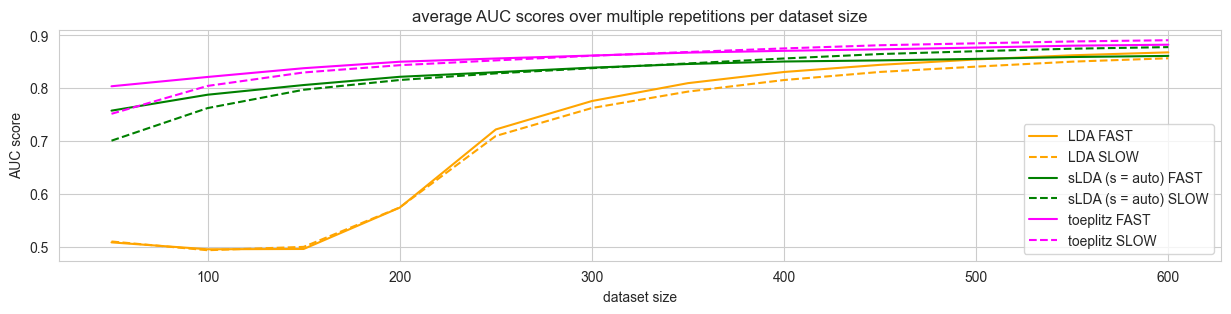

Dataset sizes: 		[ 50 100 150 200 250 300 350 400 450 500 550 600]
Repetitions per size: 	[170. 160. 150. 140. 130. 120. 110. 100.  90.  80.  70.  60.]
Step size: 10


In [116]:
step_size = 10
sizes = np.array([50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600])
scores_wo, scores_w, scores_bt, repeats = auc_repeating_sizes(sizes, step_size = step_size, tracker=False)
# Complete plotting of the above
plt.figure(figsize=(15, 3))
plt.plot(sizes, np.mean(scores_wo, axis=0)[0].T, label="LDA FAST", color='orange')
plt.plot(sizes, np.mean(scores_wo, axis=0)[1].T, label="LDA SLOW",linestyle='dashed', color='orange')

plt.plot(sizes, np.mean(scores_w, axis=0)[0].T, label="sLDA (s = auto) FAST", color='green')
plt.plot(sizes, np.mean(scores_w, axis=0)[1].T, label="sLDA (s = auto) SLOW", linestyle='dashed', color='green')

plt.plot(sizes, np.mean(scores_bt, axis=0)[0].T, label="toeplitz FAST", color = 'magenta')
plt.plot(sizes, np.mean(scores_bt, axis=0)[1].T, label="toeplitz SLOW", linestyle='dashed', color = 'magenta')
plt.xlabel("dataset size")
plt.ylabel("AUC score")
plt.legend()
plt.title("average AUC scores over multiple repetitions per dataset size")
plt.show()

print("Dataset sizes: \t\t{}".format(sizes))
print("Repetitions per size: \t{}".format(repeats))
print("Step size: {}".format(step_size))


## (optional) Exercise 7: Permutation testing
You might observe that in the previous analyses, sometimes the classifier is performing around chance level (50%). Despite that (under an engineering perspective) one may conclude the classifier did a poor job, one (under a neuroscientific perspective) can be very interested in whether it is *just* above chance level, as it means that there is just some decodable information at that location (being in time or space). A common and very flexible way of significance testing in such scenario is to perform **permutation testing**. 

From Wikipedia: "A permutation test (also called a randomization test, re-randomization test, or an exact test) is a type of statistical significance test in which the distribution of the test statistic under the null hypothesis is obtained by calculating all possible values of the test statistic under all possible rearrangements of the observed data points."

To put it into context. In our dataset we are interested in whether we can decode target versus non-target from the data. For this, we got data samples that are tuples containing $(X_i, y_i)$, the data and the target label. Now, within a permutation test, we randomize (permute) the particular structure we are originally interested in, in this case the pairing of $X_i$ with $y_i$. Concretely, here we can basically randomize this by shuffling the vector $y=[y_1, y_2, ..., y_N]$ to e.g. $y_{permuted}=[y_3, y_N, ..., y_2]$. We perform the same analysis on this shuffled dataset, and save its result. If we do this many times (in the order of 1000 times), we obtain a so-called **permutation distribution** of the test statistic (e.g. classification performance). We can then look-up where in this distribution we can find our original test statistic (i.e., the one without shuffling the labels). We say that the original test statistic is significantly above chance if no more than 5% of the samples in the permutation distribution are higher than the original test statistic ($\alpha=.05$).

1. Implement this permutation test for the decoding over time at time interval -50ms. **Hint:** it requires you to write a loop over the analysis that is provided already, and to shuffle the labeling in `y` e.g. with `np.random.permutation()`;
1. Plot the permutation distribution. What does it look like, can you explain its shape?
1. Is the decoding at this time interval significant?

In [ ]:
# Answer here

OptionError: No such keys(s): 'mode.use_inf_as_null'

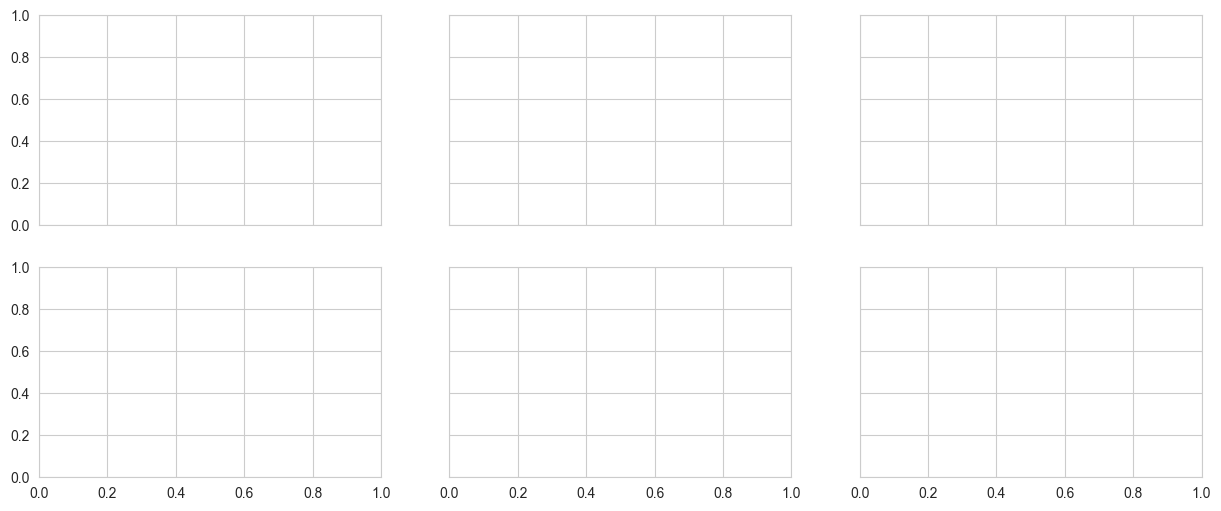

In [ ]:
# Solution
time = -0.05

# for debugging bc the env of BT-LDA works with an outdated version of seaborn
# sns.mode.use_inf_as_null = True  # Manually set the option

# Note, the higher this number, the more accurate the permutation distribution, but the higher the computational load
n_permutations = 1000  
n_permutations = 10 # to be removed

# sklearn will reinitialize on every call to fit
lda = LDA(solver='lsqr', shrinkage='auto')

scores = np.zeros((len(session_list), len(condition_list)))
permutations = np.zeros((len(session_list), len(condition_list), n_permutations))

fig, ax = plt.subplots(len(condition_list), len(session_list), figsize=(15,6), sharex=True, sharey=True)

for s_i, session in enumerate(session_list):
    for c_i, condition in enumerate(condition_list):

        # Get the data
        epo = all_data[session][condition]
        X = epo.get_data()[:,:,epo.time_as_index(time)].squeeze()
        y = epo.events[:,2]
        
        # Estimate observed performance
        scores[s_i, c_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()

        # Estimate permutation distribution
        for i in range(n_permutations):
            permutations[s_i, c_i, i] = cross_val_score(lda, X, np.random.permutation(y), cv=5, scoring='roc_auc').mean()
            
        # Plot the permutation distribution
        sns.histplot(permutations[s_i, c_i, :], stat='density', kde=True, ax=ax[c_i, s_i])

        # Mark the observed accuracy
        ax[c_i, s_i].plot(scores[s_i, c_i], 1, '*r')
        ax[c_i, s_i].set_title(f"{session} {condition}")
        
        # Print statistics
        print("session {}, condition {}: score={:.2f}, p={:.3f}".format(
            session, condition, scores[s_i, c_i], np.mean(permutations[s_i, c_i, :]>=scores[s_i, c_i])))

plt.show()
# 2. Shape of distribution: should be somewhat normally distributed.

# 3. Significant: those p values that are under alpha=.05. Clearly, subject 3 condition slow is not significant.


In [ ]:
def permutation_testing(classifier):
    # From solution
    time = -0.05

    # Note, the higher this number, the more accurate the permutation distribution, but the higher the computational load
    n_permutations = 1000  

    # sklearn will reinitialize on every call to fit
    lda = LDA(solver='lsqr', shrinkage='auto')

    scores = np.zeros((len(session_list), len(condition_list)))
    permutations = np.zeros((len(session_list), len(condition_list), n_permutations))

    fig, ax = plt.subplots(len(condition_list), len(session_list), figsize=(15,6), sharex=True, sharey=True)

    for s_i, session in enumerate(session_list):
        for c_i, condition in enumerate(condition_list):

            # Get the data
            epo = all_data[session][condition]
            X = epo.get_data()[:,:,epo.time_as_index(time)].squeeze()
            y = epo.events[:,2]
            
            # Estimate observed performance
            scores[s_i, c_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()

            # Estimate permutation distribution
            for i in range(n_permutations):
                permutations[s_i, c_i, i] = cross_val_score(lda, X, np.random.permutation(y), cv=5, scoring='roc_auc').mean()
                
            # Plot the permutation distribution
            sns.histplot(permutations[s_i, c_i, :], stat='density', kde=True, ax=ax[c_i, s_i])
            
            # Mark the observed accuracy
            ax[c_i, s_i].plot(scores[s_i, c_i], 1, '*r')
            ax[c_i, s_i].set_title(f"{session} {condition}")
            
            # Print statistics
            print("session {}, condition {}: score={:.2f}, p={:.3f}".format(
                session, condition, scores[s_i, c_i], np.mean(permutations[s_i, c_i, :]>=scores[s_i, c_i])))

    plt.show()
    # 2. Shape of distribution: should be somewhat normally distributed.

    # 3. Significant: those p values that are under alpha=.05. Clearly, subject 3 condition slow is not significant.


## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here